# Sunspots: the 20th-century "Grand Maximum"

This example applies *bayesloop* to an open question in solar physics. The Sun's
activity rises and falls in a ~11-year cycle, but the strength of successive cycles
also wanders. The mid-20th-century cycles (18–22, ≈1947–2000) were unusually strong,
forming the "Modern Grand Maximum" that Solanki et al. (*Nature*, 2004) argued was
the most active the Sun had been in 8,000 years. When SILSO recalibrated the entire
sunspot-number series in 2015 (Clette et al.), however, the apparent uniqueness of
that maximum was sharply reduced. The most recent cycles, 24–25, are the weakest in a
century.

The question is whether the sequence of cycle amplitudes really contains a secular
*envelope* (a genuine rise-and-fall in cycle strength), or whether it is a constant
average overlaid with large random cycle-to-cycle scatter. This is a problem of model
selection, for which *bayesloop* is well suited. We reduce the oscillating record to
one number per cycle, the peak amplitude, and then let *bayesloop* score three
hypotheses by their marginal likelihood. In the course of the analysis we use the
`Gaussian` observation model, a `HyperStudy` for the time-varying envelope, a
`ChangepointStudy`, the `Static`, `GaussianRandomWalk` and `ChangePoint` transition
models, and a custom flat-prior observation model for a prior-sensitivity check.

In [1]:
%matplotlib inline
import io
import urllib.request

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import bayesloop as bl

try:
    import seaborn as sns
    sns.set_style("whitegrid")
except ImportError:
    plt.style.use("default")
mpl.rcParams.update({
    "figure.dpi": 110, "font.size": 10.5, "axes.titlesize": 12,
    "axes.titleweight": "bold", "axes.edgecolor": "#444444", "grid.color": "#d9d9d9",
})
C = {"data": "#8a8a8a", "accent": "#c1272d", "accent2": "#0b6e99",
     "green": "#2e7d32", "amber": "#e8a33d", "muted": "#8a8a8a",
     "band": "#c1272d", "band2": "#0b6e99"}


def posterior_band(S, name, lo=0.05, hi=0.95):
    """Posterior mean and an equal-tailed credible band for a time-varying parameter."""
    x, p = S.get_parameter_distributions(name, density=False)
    p = np.asarray(p, dtype=float)
    p /= p.sum(axis=1, keepdims=True)
    mean = (p * x[None, :]).sum(axis=1)
    cdf = np.cumsum(p, axis=1)
    low = np.array([np.interp(lo, cdf[t], x) for t in range(p.shape[0])])
    high = np.array([np.interp(hi, cdf[t], x) for t in range(p.shape[0])])
    return mean, low, high


def prob_in(S, name, lo=None, hi=None):
    """Posterior probability the parameter lies in (lo, hi] at each time step."""
    x, p = S.get_parameter_distributions(name, density=False)
    p = np.asarray(p, dtype=float)
    p /= p.sum(axis=1, keepdims=True)
    mask = np.ones_like(x, dtype=bool)
    if lo is not None:
        mask &= x > lo
    if hi is not None:
        mask &= x <= hi
    return p[:, mask].sum(axis=1)

## The data

We use the yearly mean total sunspot number from
[SILSO](https://www.sidc.be/SILSO/datafiles) (the World Data Center at the Royal
Observatory of Belgium), the canonical 1700–present record. It is a semicolon-separated
CSV with no header; the first two columns are the fractional year and the yearly mean
sunspot number.

From this series we extract the peak amplitude of each solar cycle since Cycle 1
(≈1750) by locating the cycle maxima with `scipy.signal.find_peaks` (minimum spacing
of 7 years, prominence 20). Working with cycle amplitudes, rather than the raw
oscillating series, isolates exactly the quantity the scientific debate is about.

In [2]:
from scipy.signal import find_peaks

urls = ["https://www.sidc.be/SILSO/INFO/snytotcsv.php",
        "https://www.sidc.be/silso/INFO/snytotcsv.php"]
raw = None
for u in urls:
    try:
        req = urllib.request.Request(u, headers={"User-Agent": "Mozilla/5.0 (bayesloop docs)"})
        raw = urllib.request.urlopen(req, timeout=90).read()
        break
    except Exception:  # noqa: BLE001
        continue

df = pd.read_csv(io.BytesIO(raw), sep=";", header=None,
                 names=["frac_year", "ssn", "std", "nobs", "flag"])
df["year"] = df["frac_year"].astype(int)
df = df[(df["year"] >= 1700) & (df["year"] <= 2025)].reset_index(drop=True)
yr = df["year"].values
ssn = df["ssn"].values

# Solar-cycle peak amplitudes (reliable telescopic era, Cycle 1 onward ~1750).
pk, _ = find_peaks(ssn, distance=7, prominence=20)
pk = pk[yr[pk] >= 1750]
peak_years = yr[pk].astype(float)
amp = ssn[pk].astype(float)
print(f"{len(amp)} solar cycles (1750-): mean amplitude {amp.mean():.0f}, "
      f"range {amp.min():.0f}-{amp.max():.0f}")

26 solar cycles (1750-): mean amplitude 170, range 76-269


## A Gaussian model with a time-varying envelope

We model the amplitude sequence with a `Gaussian` observation model: each cycle's
peak amplitude is Gaussian about a slowly varying expected amplitude (`amp`) with an
inferred cycle-to-cycle scatter (`scatter`). The scatter parameter makes the large
intrinsic variability of solar cycles explicit and lets the model decide how much of
the wandering is signal and how much is noise.

```python
bl.om.Gaussian("amp", ..., "scatter", ...)
```

For the dynamics of the mean amplitude we first allow a secular envelope: a
`GaussianRandomWalk` on `amp`, wrapped in a `HyperStudy` that marginalises over the
unknown step size (`sigma`) of that drift.

In [3]:
def gauss():
    return bl.om.Gaussian("amp", bl.cint(40, 300, 220), "scatter", bl.oint(5, 110, 60))


# ---- Time-varying amplitude envelope --------------------------------------
Se = bl.HyperStudy()
Se.load_data(amp, timestamps=peak_years)
Se.set(gauss(), bl.tm.GaussianRandomWalk("sigma", bl.cint(0, 45, 30), target="amp"))
Se.fit(silent=True)
env_m, env_lo, env_hi = posterior_band(Se, "amp")

+ Created new study.
  --> Hyper-study
+ Successfully imported array.
+ Observation model: Gaussian observations. Parameter(s): ['amp', 'scatter']
+ Transition model: Gaussian random walk. Hyper-Parameter(s): ['sigma']


! WARNING: Time stamps are not equally spaced. This may result in false plotting of parameter distributions.


## Comparing an envelope with a constant mean

The envelope above assumes that the cycle strength drifts, and it is not yet clear
whether the data support that assumption. Because every model here shares the
identical observation model and data, their log₁₀ marginal likelihoods
(`S.log10_evidence`) are directly comparable. We compare three hypotheses:

| Hypothesis | Transition model | Question |
|---|---|---|
| Constant mean (null) | `tm.Static()` | one average amplitude + random scatter |
| Time-varying envelope | `tm.GaussianRandomWalk` (HyperStudy) | a genuine secular rise-and-fall |
| Single change-point | `tm.ChangePoint` (ChangepointStudy) | one regime shift in cycle strength |

In [4]:
# ---- Model selection: secular envelope vs constant mean -------------------
S0 = bl.Study(); S0.load_data(amp, timestamps=peak_years); S0.set(gauss(), bl.tm.Static()); S0.fit(silent=True)
Scp = bl.ChangepointStudy(); Scp.load_data(amp, timestamps=peak_years)
Scp.set(gauss(), bl.tm.ChangePoint("t_change", "all")); Scp.fit(silent=True)
cp_x, cp_p = Scp.get_hyper_parameter_distribution("t_change")

evid = {
    "Constant mean": float(S0.log10_evidence),
    "Time-varying envelope": float(Se.log10_evidence),
    "Single change-point": float(Scp.log10_evidence),
}
best = max(evid, key=evid.get)

+ Created new study.
+ Successfully imported array.
+ Observation model: Gaussian observations. Parameter(s): ['amp', 'scatter']
+ Transition model: Static/constant parameter values. Hyper-Parameter(s): []
+ Created new study.
  --> Hyper-study
  --> Change-point analysis
+ Successfully imported array.
+ Observation model: Gaussian observations. Parameter(s): ['amp', 'scatter']
+ Transition model: Change-point. Hyper-Parameter(s): ['t_change']
+ Detected 1 change-point(s) in transition model: ['t_change']
+ Set hyper-prior(s): ['uniform']


### Robustness of the verdict to the prior

When models are this close, the conclusion could in principle depend on the prior. We
repeat the constant-versus-envelope comparison with a deliberately flat prior on the
Gaussian parameters (supplied as a one-line `prior=` lambda on the observation model)
and check that the sign of the evidence difference does not flip.

In [5]:
def gauss_flat():
    return bl.om.Gaussian("amp", bl.cint(40, 300, 220), "scatter", bl.oint(5, 110, 60),
                          prior=lambda amp, scatter: np.ones_like(amp))


S0f = bl.Study(); S0f.load_data(amp, timestamps=peak_years); S0f.set(gauss_flat(), bl.tm.Static()); S0f.fit(silent=True)
Sef = bl.HyperStudy(); Sef.load_data(amp, timestamps=peak_years)
Sef.set(gauss_flat(), bl.tm.GaussianRandomWalk("sigma", bl.cint(0, 45, 30), target="amp")); Sef.fit(silent=True)
prior_sensitivity = {
    "jeffreys": float(S0.log10_evidence - Se.log10_evidence),
    "flat": float(S0f.log10_evidence - Sef.log10_evidence),
}

+ Created new study.
+ Successfully imported array.
+ Observation model: Gaussian observations. Parameter(s): ['amp', 'scatter']
+ Transition model: Static/constant parameter values. Hyper-Parameter(s): []
+ Created new study.
  --> Hyper-study
+ Successfully imported array.
+ Observation model: Gaussian observations. Parameter(s): ['amp', 'scatter']
+ Transition model: Gaussian random walk. Hyper-Parameter(s): ['sigma']


## Reading off the eras

Finally we quote some model-free magnitudes directly from the amplitude series, namely
the Modern Maximum, the Dalton Minimum and the recent decline, together with the
inferred envelope level at two reference cycles (≈1905 and ≈1957), so we can see how
high the secular envelope climbs through the 20th century.

In [6]:
# Modern Maximum (cycles peaking 1947-2000) vs long-term; Dalton Minimum; recent.
mm = amp[(peak_years >= 1945) & (peak_years <= 2002)]
dalton = amp[(peak_years >= 1798) & (peak_years <= 1825)]
recent = amp[peak_years >= 2008]

# Inferred envelope level at two reference cycles.
i1900 = np.argmin(np.abs(peak_years - 1905))
i1960 = np.argmin(np.abs(peak_years - 1957))

print("\nMODEL EVIDENCE (log10):")
for k, v in evid.items():
    print(f"  {k:24s} {v:8.2f}")
print(f"  best: {best}")
print(f"Long-term mean amplitude {amp.mean():.0f}; Modern Max (1947-2000) {mm.mean():.0f}; "
      f"Dalton (1804-16) {dalton.mean():.0f}; recent (>=2008) {recent.mean():.0f}")
print(f"Modern-Max excess over long-term mean: {mm.mean() - amp.mean():+.0f}")
print(f"Inferred envelope: 1905 ~ {env_m[i1900]:.0f}  ->  1957 ~ {env_m[i1960]:.0f}")
print(f"Prior sensitivity (constant - envelope, log10): "
      f"Jeffreys {prior_sensitivity['jeffreys']:+.2f}, "
      f"flat {prior_sensitivity['flat']:+.2f}  (both narrowly favour constant)")


MODEL EVIDENCE (log10):
  Constant mean              -63.11
  Time-varying envelope      -63.38
  Single change-point        -63.49
  best: Constant mean
Long-term mean amplitude 170; Modern Max (1947-2000) 207; Dalton (1804-16) 78; recent (>=2008) 134
Modern-Max excess over long-term mean: +37
Inferred envelope: 1905 ~ 153  ->  1957 ~ 197
Prior sensitivity (constant - envelope, log10): Jeffreys +0.27, flat +0.38  (both narrowly favour constant)


The model evidence settles the question. The three models land within ≲ 0.4 log₁₀ of
one another, and the constant-mean model narrowly wins. The conclusion is therefore
that there is no compelling statistical evidence that the cycle-amplitude envelope
varies: the entire 26-cycle sequence, Dalton Minimum and Modern Maximum included, is
barely distinguishable from a constant mean of ~170 with large (~50) random
cycle-to-cycle scatter. The verdict is robust to the prior (the constant model leads
by roughly +0.4 log₁₀ under a flat prior versus +0.3 under the default Jeffreys
prior), so it does not depend on that choice.

Quantitatively, the Modern-Maximum cycles (1947–2000) averaged ~207 versus the
long-term ~170, an excess of only ~+37, which is less than one cycle-to-cycle
standard deviation. The Dalton Minimum (~78) is the single most pronounced excursion,
and it is the only feature the envelope resolves with much confidence.

## Visualising the record and the envelope

The top panel shows the familiar three-century sunspot record with the per-cycle peak
amplitudes marked; the bottom panel shows those amplitudes with the inferred envelope
and its 90% credible band, against the long-term mean. The shaded spans mark the
Dalton Minimum, the Modern Grand Maximum, and the recent decline.

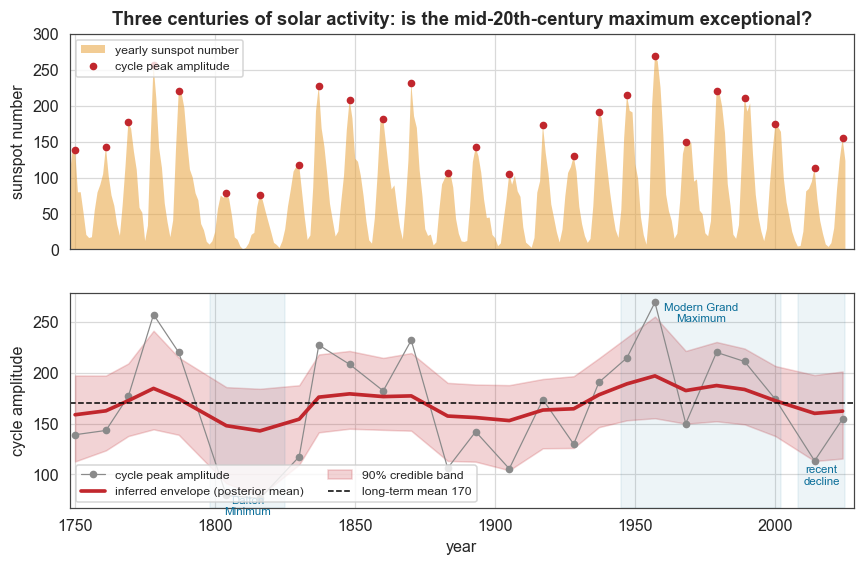

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.2, 5.6), sharex=True)
ax1.fill_between(yr, 0, ssn, color=C["amber"], alpha=0.55, lw=0, label="yearly sunspot number")
ax1.plot(peak_years, amp, "o", ms=4, color=C["accent"], label="cycle peak amplitude")
ax1.set_ylabel("sunspot number")
ax1.set_title("Three centuries of solar activity: is the mid-20th-century maximum exceptional?")
ax1.legend(loc="upper left", fontsize=8)
ax1.set_ylim(0, 300)

ax2.plot(peak_years, amp, "o-", ms=4, color=C["muted"], lw=0.8, label="cycle peak amplitude")
ax2.plot(peak_years, env_m, color=C["accent"], lw=2.4, label="inferred envelope (posterior mean)")
ax2.fill_between(peak_years, env_lo, env_hi, color=C["band"], alpha=0.2, label="90% credible band")
ax2.axhline(amp.mean(), color="k", ls="--", lw=1, label=f"long-term mean {amp.mean():.0f}")
for x0, x1, txt, yy in [(1798, 1825, "Dalton\nMinimum", 60),
                        (1945, 2002, "Modern Grand\nMaximum", 250),
                        (2008, 2025, "recent\ndecline", 90)]:
    ax2.axvspan(x0, x1, color=C["accent2"], alpha=0.07)
    ax2.text((x0 + x1) / 2, yy, txt, ha="center", fontsize=7.5, color=C["accent2"])
ax2.set_ylabel("cycle amplitude")
ax2.set_xlabel("year")
ax2.set_xlim(1748, 2028)
ax2.legend(loc="lower left", ncol=2, fontsize=8)
plt.show()

The envelope dips during the Dalton Minimum (~1800–1820, down to ~80), rises through
the Modern Grand Maximum (~200 around 1957), and falls again into the recent decline
(cycles 24–25). As the evidence comparison below makes explicit, however, that
visually salient rise-and-fall is not strong enough to beat a flat line once the
Occam penalty for the extra flexibility is paid.

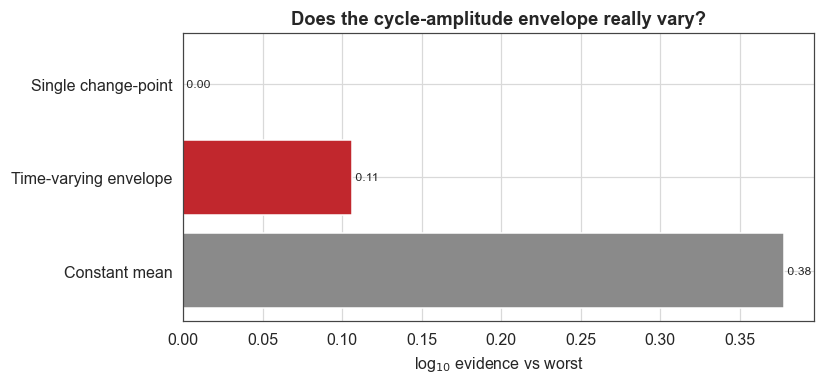

In [8]:
fig, ax = plt.subplots(figsize=(7.4, 3.4))
labels = list(evid.keys())
vals = np.array([evid[k] for k in labels]) - min(evid.values())
ax.barh(labels, vals, color=[C["muted"], C["accent"], C["green"]])
ax.set_xlabel(r"log$_{10}$ evidence vs worst")
ax.set_title("Does the cycle-amplitude envelope really vary?")
for i, v in enumerate(vals):
    ax.text(v, i, f" {v:.2f}", va="center", fontsize=8)
plt.show()

## The scientific conclusion

*bayesloop* sides with the post-recalibration view (Clette et al., 2014; Usoskin et
al.): once the large intrinsic variability of solar cycles is accounted for, the
Modern Grand Maximum is not statistically exceptional. It is a run of strong cycles
within the normal range of solar variability, not evidence of a fundamentally
different solar state. The Dalton Minimum stands out more clearly than the Modern
Maximum. This is a textbook example of a striking-looking feature failing a rigorous
significance test.

The amplitudes are taken from the yearly SILSO v2.0 series, which slightly understates
true cycle maxima (smoothed monthly values are the convention) but does so
consistently across cycles; pre-1749 cycles are excluded as less reliable.

## What this example showed

On a single dataset we used *bayesloop* to:

- weigh an open and recently reopened question (Solanki 2004 versus the 2015
  recalibration) with a transparent model-evidence calculation rather than by
  eyeballing a curve;
- obtain a result in which the simpler model wins, with the constant-mean model
  narrowly beating both a time-varying envelope (`HyperStudy` + `GaussianRandomWalk`)
  and a single `ChangePoint`, showing that *bayesloop*'s model selection resists
  over-interpreting visually salient features;
- model the right quantity, reducing the oscillating record to per-cycle amplitudes
  so that the analysis targets exactly the debated quantity, with the inferred
  `scatter` parameter making the large intrinsic variability explicit;
- test the verdict against the prior with a one-line custom flat-prior `Gaussian`
  observation model, confirming that the narrow result does not depend on the prior
  choice.